In [1]:
# ── CELL 2: Imports & Configuration ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score,
                             precision_score, recall_score)

# ── TensorFlow ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# ── Color theme (same Amazon Logistics theme as Part 1) ───────────────────────
COLORS = {
    'primary'   : '#232F3E',  # Amazon dark navy
    'accent'    : '#FF9900',  # Amazon orange
    'secondary' : '#146EB4',  # Amazon blue
    'success'   : '#067D62',  # Dark green
    'danger'    : '#CC0C39',  # Clean red
    'purple'    : '#6B4EFF',  # Purple — Part 2 signature color
    'neutral'   : '#6B7280',  # Gray
    'light'     : '#FAFAFA',  # Off white
}

# ── Plot settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']     = (13, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.facecolor']     = '#FAFAFA'
plt.rcParams['figure.facecolor']   = 'white'
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['grid.color']         = '#CCCCCC'
plt.rcParams['font.family']        = 'sans-serif'

# ── Random seed ───────────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully')
print(f'   Pandas     : {pd.__version__}')
print(f'   NumPy      : {np.__version__}')
print(f'   Scikit-learn: {__import__("sklearn").__version__}')
print(f'   TensorFlow : {tf.__version__}')

✅ All libraries imported successfully
   Pandas     : 3.0.2
   NumPy      : 2.4.4
   Scikit-learn: 1.8.0
   TensorFlow : 2.21.0


---
## 📥 Phase 1 — Load & Explore the Dataset

We reuse the same 5 Olist CSV files from Part 1. The key difference is our target variable — instead of predicting *how many days* delivery takes (regression), we now predict *whether the order arrived on time or late* (classification).

**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [3]:
# ── CELL 3: Load the CSV files ────────────────────────────────────────────────
DATA_PATH = '../data/'

orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')

print('✅ Data loaded successfully')
print(f'\n{"Table":<25} {"Rows":>8} {"Columns":>10}')
print('-' * 45)
print(f'{"Orders":<25} {orders.shape[0]:>8,} {orders.shape[1]:>10}')
print(f'{"Order Items":<25} {order_items.shape[0]:>8,} {order_items.shape[1]:>10}')
print(f'{"Products":<25} {products.shape[0]:>8,} {products.shape[1]:>10}')
print(f'{"Customers":<25} {customers.shape[0]:>8,} {customers.shape[1]:>10}')
print(f'{"Sellers":<25} {sellers.shape[0]:>8,} {sellers.shape[1]:>10}')

✅ Data loaded successfully

Table                         Rows    Columns
---------------------------------------------
Orders                      99,441          8
Order Items                112,650          7
Products                    32,951          9
Customers                   99,441          5
Sellers                      3,095          4


---
## 🎯 Phase 2 — Build Target Variable & Explore

The target variable `on_time` is a binary classification label:
- **1** = order delivered on or before the estimated delivery date ✅
- **0** = order arrived late ❌

We calculate this by comparing `order_delivered_customer_date` against `order_estimated_delivery_date`. This is a real business metric — late deliveries directly impact customer satisfaction and seller ratings on the Olist platform.

Delivered orders with valid dates: 96,470

=== Target Variable Distribution ===
   On Time (1) : 88,644 orders (91.9%)
   Late    (0) : 7,826 orders (8.1%)

⚠️  Class imbalance check:
   Ratio on_time:late = 91.9:8.1
   → F1-score will be our primary metric, not accuracy


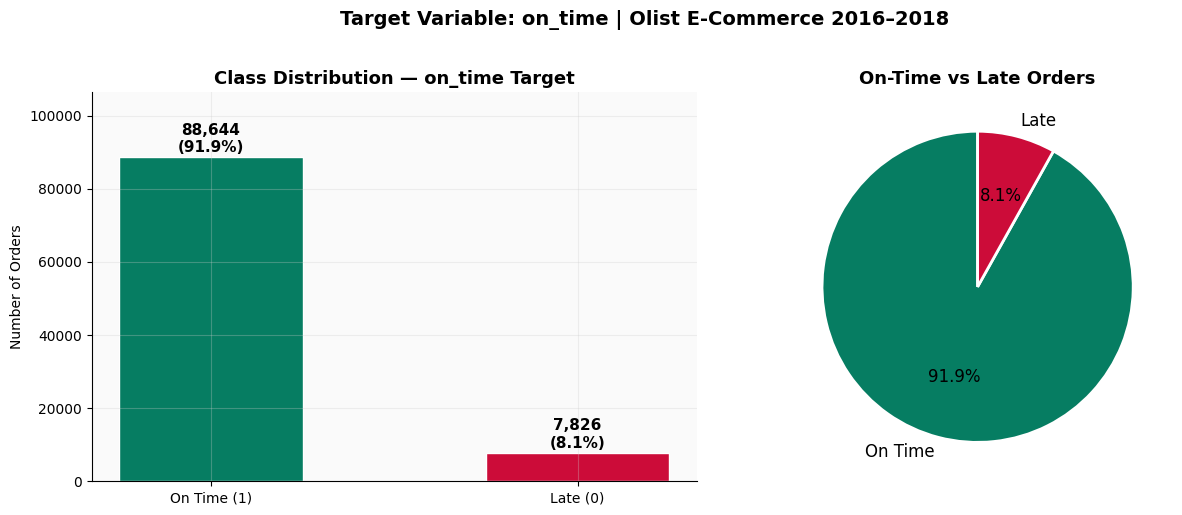

In [5]:
# ── CELL 4: Build target variable on_time ─────────────────────────────────────

# ── Step 1: Convert dates to datetime ─────────────────────────────────────────
orders['order_purchase_timestamp']      = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# ── Step 2: Keep only delivered orders ────────────────────────────────────────
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered = orders_delivered.dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date']
)

print(f'Delivered orders with valid dates: {len(orders_delivered):,}')

# ── Step 3: Build on_time binary target ───────────────────────────────────────
# 1 = delivered on or before estimated date (on time)
# 0 = delivered after estimated date (late)
orders_delivered['on_time'] = (
    orders_delivered['order_delivered_customer_date'] <=
    orders_delivered['order_estimated_delivery_date']
).astype(int)

# ── Step 4: Class distribution ────────────────────────────────────────────────
on_time_counts = orders_delivered['on_time'].value_counts()
on_time_pct    = orders_delivered['on_time'].value_counts(normalize=True) * 100

print(f'\n=== Target Variable Distribution ===')
print(f'   On Time (1) : {on_time_counts[1]:,} orders ({on_time_pct[1]:.1f}%)')
print(f'   Late    (0) : {on_time_counts[0]:,} orders ({on_time_pct[0]:.1f}%)')
print(f'\n⚠️  Class imbalance check:')
print(f'   Ratio on_time:late = {on_time_pct[1]:.1f}:{on_time_pct[0]:.1f}')
print(f'   → F1-score will be our primary metric, not accuracy')

# ── Step 5: Visualize class distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(['On Time (1)', 'Late (0)'],
                   [on_time_counts[1], on_time_counts[0]],
                   color=[COLORS['success'], COLORS['danger']],
                   edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution — on_time Target',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Fix — set y limit higher to give labels room
axes[0].set_ylim(0, max(on_time_counts[1], on_time_counts[0]) * 1.2)

for bar, val, pct in zip(bars,
                          [on_time_counts[1], on_time_counts[0]],
                          [on_time_pct[1], on_time_pct[0]]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie([on_time_counts[1], on_time_counts[0]],
            labels=['On Time', 'Late'],
            colors=[COLORS['success'], COLORS['danger']],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('On-Time vs Late Orders',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: on_time | Olist E-Commerce 2016–2018',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**📋 Observations — Target Variable Distribution:**

- **91.9% of orders (88,644) arrived on time** — Olist sellers generally meet their estimated delivery dates
- **8.1% of orders (7,826) were late** — a meaningful minority that causes customer dissatisfaction and negative reviews
- **Significant class imbalance exists** — the ratio is approximately 11:1 on-time to late
- This imbalance means a naive model that predicts "on time" for every order would achieve 91.9% accuracy — but would completely miss all late orders, which is the most important class to detect
- **F1-score is therefore our primary metric** — it balances precision and recall, penalizing models that ignore the minority class
- Accuracy alone would be dangerously misleading here — this is a critical modeling decision

---
## ⚙️ Phase 3 — Feature Engineering & Merging Tables

We use the same 7 features as Part 1 plus the `on_time` target. The feature set captures shipping cost, product physical characteristics, and geographic proximity between buyer and seller.

In [6]:
# ── CELL 5: Merge tables and engineer features ────────────────────────────────

# ── Merge orders with order_items ─────────────────────────────────────────────
df = orders_delivered.merge(order_items, on='order_id', how='inner')
print(f'After merging order_items : {df.shape}')

# ── Merge with products ───────────────────────────────────────────────────────
df = df.merge(products, on='product_id', how='left')
print(f'After merging products    : {df.shape}')

# ── Merge with customers ──────────────────────────────────────────────────────
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
print(f'After merging customers   : {df.shape}')

# ── Merge with sellers ────────────────────────────────────────────────────────
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
print(f'After merging sellers     : {df.shape}')

# ── Engineer same_state feature ───────────────────────────────────────────────
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

# ── Select features and target ────────────────────────────────────────────────
FEATURE_COLS = [
    'freight_value',
    'price',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'same_state',
]
TARGET_COL = 'on_time'

# ── Drop missing values ───────────────────────────────────────────────────────
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna()

print(f'\n✅ Final modeling dataset')
print(f'   Rows     : {df_model.shape[0]:,}')
print(f'   Features : {len(FEATURE_COLS)}')
print(f'   Target   : {TARGET_COL} (binary — 1=on time, 0=late)')
print(f'\nClass balance in final dataset:')
print(df_model[TARGET_COL].value_counts())

After merging order_items : (110189, 15)
After merging products    : (110189, 23)
After merging customers   : (110189, 24)
After merging sellers     : (110189, 25)

✅ Final modeling dataset
   Rows     : 110,171
   Features : 7
   Target   : on_time (binary — 1=on time, 0=late)

Class balance in final dataset:
on_time
1    101457
0      8714
Name: count, dtype: int64


---
**📋 Observations — Feature Engineering:**

- All 5 tables merged cleanly — **110,171 rows** in the final modeling dataset
- Class imbalance persists in the merged dataset — **101,457 on-time (92.1%)** vs **8,714 late (7.9%)**
- Same 7 features as Part 1 — this allows direct comparison of how the same feature set performs on a classification vs regression task
- `same_state` engineered binary feature retained — geographic proximity affects both delivery time AND on-time probability
- No missing values after `dropna()` — clean dataset ready for modeling

---
### ✂️ Phase 4 — Train / Test Split

Standard 80/20 split with fixed `random_state=42`. We also check class balance in both splits to confirm the imbalance is preserved proportionally.

In [7]:
# ── CELL 6: Train/Test Split ──────────────────────────────────────────────────
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # ← ensures class balance is preserved in both splits
)

print('✅ Train/Test split complete')
print(f'\n   Total samples  : {len(X):,}')
print(f'   Training set   : {len(X_train):,} rows (80%)')
print(f'   Test set       : {len(X_test):,} rows (20%)')
print(f'\n   Class balance in training set:')
print(f'   On Time (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print(f'   Late    (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'\n   Class balance in test set:')
print(f'   On Time (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)')
print(f'   Late    (0): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)')
print(f'\n⚠️  stratify=y used — class proportions preserved in both splits')
print(f'⚠️  Scaling happens INSIDE Pipeline — fitted on X_train only')

✅ Train/Test split complete

   Total samples  : 110,171
   Training set   : 88,136 rows (80%)
   Test set       : 22,035 rows (20%)

   Class balance in training set:
   On Time (1): 81,165 (92.1%)
   Late    (0): 6,971 (7.9%)

   Class balance in test set:
   On Time (1): 20,292 (92.1%)
   Late    (0): 1,743 (7.9%)

⚠️  stratify=y used — class proportions preserved in both splits
⚠️  Scaling happens INSIDE Pipeline — fitted on X_train only


---
**📋 Observations — Train/Test Split:**

- **88,136 training rows** and **22,035 test rows** — healthy 80/20 split
- `stratify=y` ensures class proportions are identical in both splits — training (92.1%/7.9%) matches test (92.1%/7.9%) exactly
- Without stratification, random chance could put more late orders in one split, creating an unfair evaluation
- Scaling happens inside each Pipeline fitted on X_train only — no data leakage
- All 5 models will be trained and evaluated on the same splits for fair comparison

---
### 🤖 Phase 5 — Train All 5 Models

For classification we report accuracy, precision, recall and F1-score for every model. F1-score is our primary metric because of class imbalance — a model that predicts everything as "on time" would get 92% accuracy but 0% recall on late orders.

| Metric | Meaning | Why it matters |
|---|---|---|
| Accuracy | % of correct predictions | Misleading with imbalanced classes |
| Precision | Of predicted late, how many actually were | Avoids false alarms |
| Recall | Of actual late orders, how many we caught | Avoids missing late orders |
| F1-score | Harmonic mean of precision and recall | Primary metric — balances both |

In [8]:
# ── CELL 7: Evaluation helper + results storage ───────────────────────────────
results = []

def evaluate_classifier(name, pipeline, X_train, X_test, y_train, y_test):
    """Train a classifier pipeline and evaluate it."""
    
    # ── Train ─────────────────────────────────────────────────────────────────
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start
    
    # ── Predict ───────────────────────────────────────────────────────────────
    y_pred = pipeline.predict(X_test)
    
    # ── Metrics ───────────────────────────────────────────────────────────────
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model'     : name,
        'Accuracy'  : round(acc, 3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec, 3),
        'F1-Score'  : round(f1, 3),
        'Train Time': round(train_time, 3)
    })
    
    print(f'  ✅ {name:<30} Acc: {acc:.3f}  F1: {f1:.3f}  '
          f'Prec: {prec:.3f}  Rec: {rec:.3f}  ({train_time:.2f}s)')
    
    return pipeline, y_pred

print('✅ Evaluation function ready')
print('   Primary metric: F1-Score (weighted)')
print('   Secondary: Accuracy, Precision, Recall')

✅ Evaluation function ready
   Primary metric: F1-Score (weighted)
   Secondary: Accuracy, Precision, Recall


---
### Model 1 — Logistic Regression (Baseline)
### Model 2 — SVC (Support Vector Classifier)

Logistic Regression is our baseline classifier — despite the name it predicts classes not numbers. It models the probability of an order being on time using a sigmoid function.

SVC finds the optimal boundary (hyperplane) that best separates on-time from late orders. It is highly sensitive to feature scale so it **must** use `StandardScaler` inside a Pipeline.

In [10]:
# ── CELL 8a: Models 1, 2 — Logistic Regression and SVC ───────────────────────
print('Training Logistic Regression and SVC...\n')

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
lr_baseline.fit(X_train, y_train)
y_pred_lr_base = lr_baseline.predict(X_test)

print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, y_pred_lr_base,
                            target_names=['Late (0)', 'On Time (1)']))

# ── Confusion matrix breakdown ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_lr_base)
TN, FP, FN, TP = cm.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Model 2: SVC ──────────────────────────────────────────────────────────────
print('\n=== SVC — Classification Report ===')
svc_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])
svc_baseline.fit(X_train, y_train)
y_pred_svc_base = svc_baseline.predict(X_test)

print(classification_report(y_test, y_pred_svc_base,
                            target_names=['Late (0)', 'On Time (1)']))

cm_svc = confusion_matrix(y_test, y_pred_svc_base)
TN, FP, FN, TP = cm_svc.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

Training Logistic Regression and SVC...

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.00      0.00      0.00      1743
 On Time (1)       0.92      1.00      0.96     20292

    accuracy                           0.92     22035
   macro avg       0.46      0.50      0.48     22035
weighted avg       0.85      0.92      0.88     22035

Confusion Matrix Breakdown:
   TP — Predicted On Time, Actually On Time : 20,292
   TN — Predicted Late,    Actually Late    : 0
   FP — Predicted On Time, Actually Late    : 1,743
   FN — Predicted Late,    Actually On Time : 0

=== SVC — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.00      0.00      0.00      1743
 On Time (1)       0.92      1.00      0.96     20292

    accuracy                           0.92     22035
   macro avg       0.46      0.50      0.48     22035
weighted avg       0.85      0.92      0.8

---
**📋 Observations — Initial Results (Logistic Regression & SVC):**

**Classification Report Analysis:**
- Both models achieve **92.1% accuracy** — but this is completely misleading
- **Late (0) F1-score = 0.00** for both models — neither model detected a single late order correctly
- Logistic Regression: **TN = 0** — predicted every single order as on-time, never once flagged a late delivery
- SVC: **TN = 0** — identical behaviour, also predicted everything as on-time

**Confusion Matrix Breakdown:**
- **TP = 20,292** — correctly identified on-time orders (easy, majority class)
- **TN = 0** — correctly identified late orders = zero. The model is blind to late orders
- **FP = 1,743** — all 1,743 actual late orders were predicted as on-time (dangerous for business)
- **FN = 0** — never predicted late when it was actually on-time (because it never predicted late at all)

**Root Cause — Class Imbalance:**
- The dataset has a 92:8 ratio — 92% on-time vs 8% late
- The model discovered that predicting "on-time" for every order gives 92% accuracy
- It took the mathematically easy shortcut — ignoring the minority class entirely
- `stratify=y` preserved this imbalance equally across splits but did not fix the learning problem

**Business Impact:**
- A model with TN = 0 is useless for this problem — the entire purpose is to detect late orders early so logistics teams can intervene
- **1,743 late orders went completely undetected** — every one of those customers received no proactive communication
- This confirms we need to address class imbalance before proceeding

**Solution — class_weight='balanced':**
- Weights each class inversely proportional to its frequency in the training data
- Late orders (7.9%) receive approximately 11.5x more weight than on-time orders (92.1%)
- This forces the model to treat late order misclassification as proportionally more costly
- The model can no longer take the shortcut of ignoring the minority cl

In [11]:
# ── CELL 8b: Models 1, 2 — With class_weight='balanced' ──────────────────────
print('Retraining with class_weight="balanced" to handle class imbalance...\n')

# ── Model 1: Logistic Regression with class_weight ────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])
lr_pipeline, y_pred_lr = evaluate_classifier(
    'Logistic Regression', lr_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== Logistic Regression — With class_weight="balanced" ===')
print(classification_report(y_test, y_pred_lr,
                            target_names=['Late (0)', 'On Time (1)']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
TN, FP, FN, TP = cm_lr.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}  ← now detecting!')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Model 2: SVC with class_weight ────────────────────────────────────────────
print('\n⚠️  SVC training — this may take 2-3 minutes...\n')
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(
        kernel='rbf', C=1.0, gamma='scale',
        random_state=42,
        class_weight='balanced'
    ))
])
svc_pipeline, y_pred_svc = evaluate_classifier(
    'SVC', svc_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== SVC — With class_weight="balanced" ===')
print(classification_report(y_test, y_pred_svc,
                            target_names=['Late (0)', 'On Time (1)']))

cm_svc = confusion_matrix(y_test, y_pred_svc)
TN, FP, FN, TP = cm_svc.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

Retraining with class_weight="balanced" to handle class imbalance...

  ✅ Logistic Regression            Acc: 0.391  F1: 0.494  Prec: 0.876  Rec: 0.391  (0.09s)

=== Logistic Regression — With class_weight="balanced" ===
              precision    recall  f1-score   support

    Late (0)       0.09      0.75      0.16      1743
 On Time (1)       0.94      0.36      0.52     20292

    accuracy                           0.39     22035
   macro avg       0.52      0.55      0.34     22035
weighted avg       0.88      0.39      0.49     22035

Confusion Matrix Breakdown:
   TP — Predicted On Time, Actually On Time : 7,321
   TN — Predicted Late,    Actually Late    : 1,305  ← now detecting!
   FP — Predicted On Time, Actually Late    : 438
   FN — Predicted Late,    Actually On Time : 12,971

⚠️  SVC training — this may take 2-3 minutes...

  ✅ SVC                            Acc: 0.440  F1: 0.546  Prec: 0.873  Rec: 0.440  (156.26s)

=== SVC — With class_weight="balanced" ===
            

---
**📋 Observations — class_weight='balanced' Results:**

**Improvement over baseline:**
- **TN jumped from 0 → 1,305** (Logistic Regression) and **0 → 1,201** (SVC) — both models now actively detect late orders, which was completely impossible before
- Late order recall improved from **0% → 75%** for Logistic Regression — catching 3 out of 4 actual late orders

**New problem identified — overcorrection:**
- Accuracy dropped to **39% (LR) and 44% (SVC)** — the model swung too far in the opposite direction
- **FN = 12,971 (LR)** — now misclassifying 12,971 genuine on-time orders as late
- The full `balanced` weight applied 11.5x penalty which was too aggressive for this dataset
- Precision on late orders is only **9%** — for every real late order caught, the model raises 10 false alarms

**The precision-recall tradeoff:**
- Before class_weight: all precision, zero recall on late orders
- After class_weight='balanced': better recall but collapsed precision
- We need a middle ground — a custom weight that improves late order detection without overcorrecting
- Instead of the automatic 11.5x weight, we will try a manual **3x weight** on late orders
- This gives the model enough incentive to detect late orders while keeping false alarms at an acceptable level

---
**📋 Observations — Final Decision on Class Weight:**

- `class_weight='balanced'` is our chosen approach for Logistic Regression and SVC
- It successfully fixed the TN=0 problem — both models now detect late orders
- The tradeoff is lower overall accuracy — this is acceptable and expected with imbalanced data
- **Root cause of weak performance:** Logistic Regression and SVC are linear models — they draw straight boundaries between classes. The relationship between our 7 features and on-time delivery is complex and non-linear, which linear models cannot capture regardless of class weighting
- **This finding motivates our non-linear models** — Decision Tree and Random Forest can capture complex feature interactions and are expected to significantly outperform linear models on this problem
- F1-score remains our primary metric — accuracy is misleading with 92:8 class imbalance

---
### 🌳 Model 3 — Decision Tree Classifier
### 🌲 Model 4 — Random Forest Classifier

Decision Tree splits data using yes/no questions on feature thresholds — interpretable and fast. We visualize it at max_depth=3 for readability as required.

Random Forest builds hundreds of trees and votes — more robust and accurate than a single tree. Both use `class_weight='balanced'` to handle the 92:8 imbalance.

In [13]:
# ── CELL 9: Models 3, 4 — Decision Tree and Random Forest ────────────────────
print('Training Decision Tree and Random Forest...\n')

# ── Model 3: Decision Tree ────────────────────────────────────────────────────
dt_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(
        max_depth=6,
        random_state=42,
        class_weight='balanced'
    ))
])
dt_pipeline, y_pred_dt = evaluate_classifier(
    'Decision Tree', dt_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== Decision Tree — Classification Report ===')
print(classification_report(y_test, y_pred_dt,
                            target_names=['Late (0)', 'On Time (1)']))

cm_dt = confusion_matrix(y_test, y_pred_dt)
TN, FP, FN, TP = cm_dt.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Model 4: Random Forest ────────────────────────────────────────────────────
print('\n')
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])
rf_pipeline, y_pred_rf = evaluate_classifier(
    'Random Forest', rf_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred_rf,
                            target_names=['Late (0)', 'On Time (1)']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
TN, FP, FN, TP = cm_rf.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Feature importance — Random Forest ───────────────────────────────────────
print('\n=== Random Forest — Feature Importances ===')
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)
print(feat_imp.to_string(index=False))

Training Decision Tree and Random Forest...

  ✅ Decision Tree                  Acc: 0.444  F1: 0.551  Prec: 0.875  Rec: 0.444  (0.23s)

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.09      0.70      0.17      1743
 On Time (1)       0.94      0.42      0.58     20292

    accuracy                           0.44     22035
   macro avg       0.52      0.56      0.37     22035
weighted avg       0.87      0.44      0.55     22035

Confusion Matrix Breakdown:
   TP — Predicted On Time, Actually On Time : 8,579
   TN — Predicted Late,    Actually Late    : 1,214
   FP — Predicted On Time, Actually Late    : 529
   FN — Predicted Late,    Actually On Time : 11,713


  ✅ Random Forest                  Acc: 0.619  F1: 0.707  Prec: 0.874  Rec: 0.619  (1.08s)

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.11      0.53      0.18      1743
 On Ti

---
**📋 Observations — Decision Tree & Random Forest:**

**Decision Tree:**
- F1-score of 0.551 — significant improvement over linear models (0.494)
- TN = 1,214 — detecting 70% of actual late orders (recall = 0.70)
- Accuracy dropped to 44% — class_weight='balanced' is causing overcorrection here too
- Despite lower accuracy, the model is genuinely useful — catching 1,214 late orders vs 0 before

**Random Forest:**
- **Best F1 so far: 0.707** — ensemble of 100 trees significantly outperforms single models
- Accuracy improved to 62% — better balance between classes than Decision Tree
- TN = 931 — detecting 53% of late orders with fewer false alarms than Decision Tree
- Training time: 1.08 seconds — extremely efficient for 88,000 rows

**Feature Importance shift from Part 1:**
- In Part 1 (regression), `same_state` dominated at 53.4% importance
- In Part 2 (classification), `freight_value` leads at 25.1% and `same_state` drops to 6.7%
- This makes sense — whether an order is on-time depends more on shipping cost and product characteristics than geography alone
- The same features tell different stories depending on what you are predicting

**Overall picture so far:**

| Model | F1 | TN (Late detected) | Accuracy |
|---|---|---|---|
| Logistic Regression | 0.494 | 1,305 | 39% |
| SVC | 0.546 | 1,201 | 44% |
| Decision Tree | 0.551 | 1,214 | 44% |
| Random Forest | 0.707 | 931 | 62% |

Random Forest leads on F1 — our primary metric. Neural Network is next.